In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Replace 'dataset.csv' with the actual file name you downloaded
df = pd.read_csv('Final_Augmented_dataset_Diseases_and_Symptoms.csv')

# Verify it loaded correctly
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (246945, 378)


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [2]:
missing_values = df.isnull().sum().sum()
print(f"Total missing values in the dataset: {missing_values}")

df.info()

Total missing values in the dataset: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246945 entries, 0 to 246944
Columns: 378 entries, diseases to neck weakness
dtypes: int64(377), object(1)
memory usage: 712.2+ MB


Number of unique diseases: 773
Top 15 most frequent diseases:
 diseases
cystitis                          1219
vulvodynia                        1218
nose disorder                     1218
complex regional pain syndrome    1217
spondylosis                       1216
hypoglycemia                      1215
peripheral nerve disorder         1215
esophagitis                       1215
vaginal cyst                      1215
conjunctivitis due to allergy     1215
diverticulitis                    1214
gastrointestinal hemorrhage       1214
acute bronchitis                  1213
pneumonia                         1212
fungal infection of the hair      1212
Name: count, dtype: int64


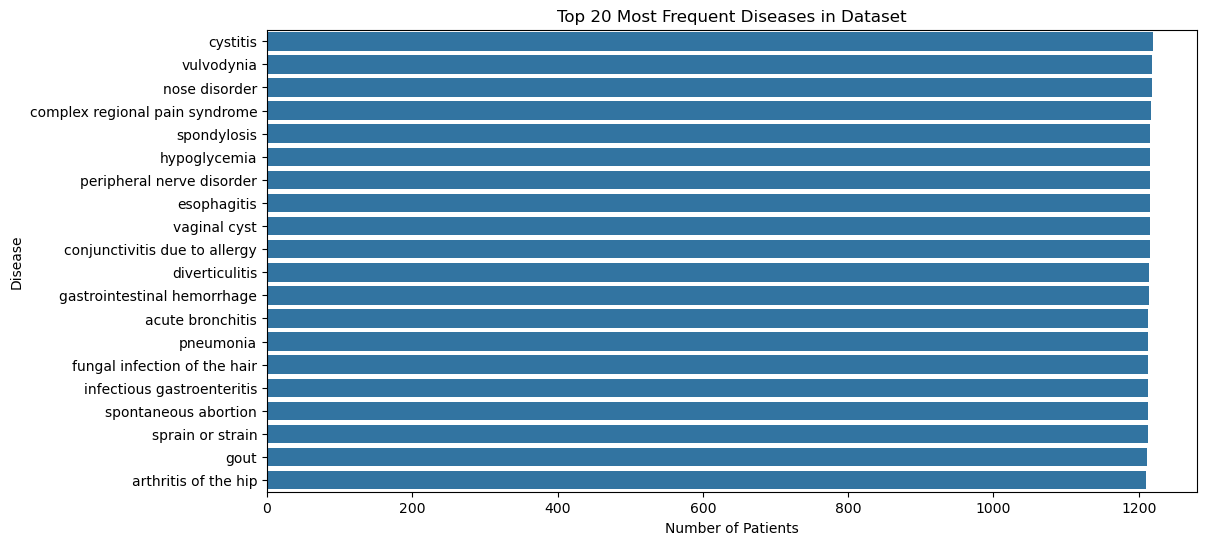

In [3]:
target_col = 'diseases'

disease_counts = df[target_col].value_counts()
print(f"Number of unique diseases: {len(disease_counts)}")
print("Top 15 most frequent diseases:\n", disease_counts.head(15))

plt.figure(figsize=(12, 6))
sns.barplot(x=disease_counts.head(20).values, y=disease_counts.head(20).index)
plt.title('Top 20 Most Frequent Diseases in Dataset')
plt.xlabel('Number of Patients')
plt.ylabel('Disease')
plt.show()

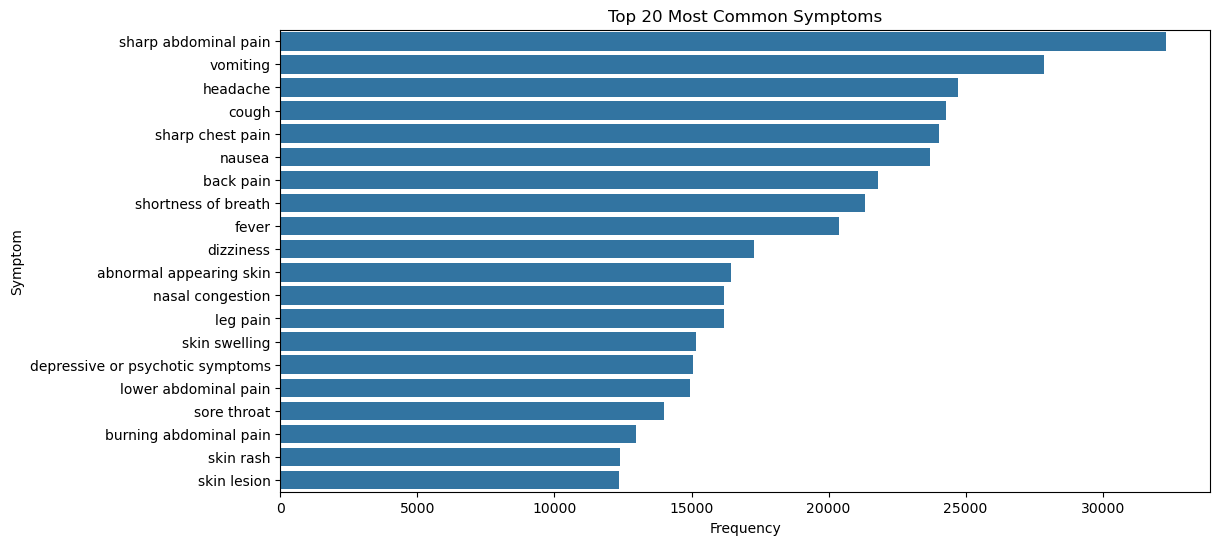

In [4]:
symptoms_only = df.drop(columns=[target_col])

symptom_frequencies = symptoms_only.sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=symptom_frequencies.head(20).values, y=symptom_frequencies.head(20).index)
plt.title('Top 20 Most Common Symptoms')
plt.xlabel('Frequency')
plt.ylabel('Symptom')
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder

# Initialize the encoder
le = LabelEncoder()

# Encode the disease labels
df['Disease_Encoded'] = le.fit_transform(df[target_col])

# Display the mapping to prove it worked
print("Sample of encoded labels:")
print(df[[target_col, 'Disease_Encoded']].head())

Sample of encoded labels:
         diseases  Disease_Encoded
0  panic disorder              531
1  panic disorder              531
2  panic disorder              531
3  panic disorder              531
4  panic disorder              531


In [8]:
from sklearn.preprocessing import LabelEncoder

# 1. Identify the top 15 most frequent diseases
target_col = 'diseases'
top_15_diseases = df[target_col].value_counts().head(15).index.tolist()

# 2. Filter the dataframe to keep only rows with these top 15 diseases
df_top15 = df[df[target_col].isin(top_15_diseases)].copy()

# 3. Check the new shape of the dataset
print(f"Original shape: {df.shape}")
print(f"Filtered shape (Top 15 Diseases only): {df_top15.shape}")

# 4. Re-encode the labels for this new subset
le = LabelEncoder()
df_top15['Disease_Encoded'] = le.fit_transform(df_top15[target_col])

Original shape: (246945, 379)
Filtered shape (Top 15 Diseases only): (18228, 379)


In [9]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Separate the features (symptoms) from the target variables in your Top 15 dataset
X = df_top15.drop(columns=['diseases', 'Disease_Encoded'])
y = df_top15['Disease_Encoded']

# Initialize the Min-Max Scaler
scaler = MinMaxScaler()

# Apply the scaler to the feature matrix
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Min-Max Normalization complete.")
print(f"Scaled feature matrix shape: {X_scaled.shape}")
print(f"Min value: {X_scaled.min().min()}, Max value: {X_scaled.max().max()}")

Min-Max Normalization complete.
Scaled feature matrix shape: (18228, 377)
Min value: 0.0, Max value: 1.0


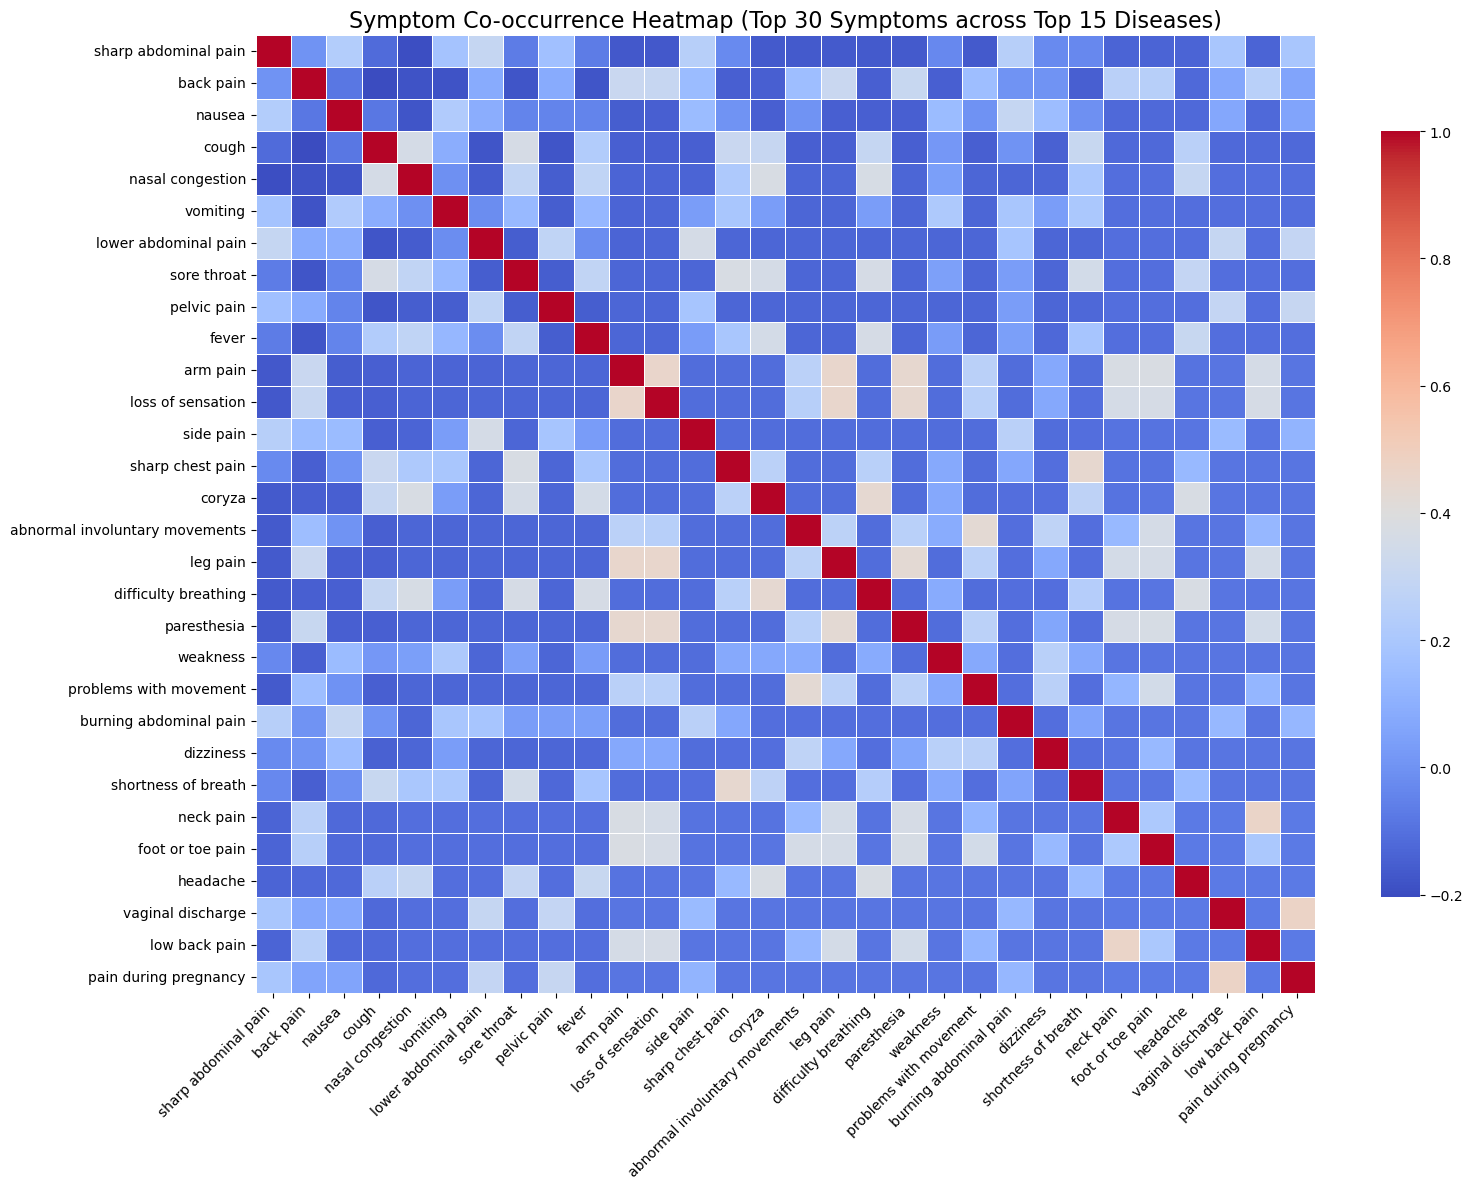

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify the top 30 symptoms within your specific top 15 disease subset
top_30_symptoms = X_scaled.sum().sort_values(ascending=False).head(30).index

# 2. Filter the scaled features to just these 30 symptoms
X_heatmap_subset = X_scaled[top_30_symptoms]

# 3. Calculate the correlation/co-occurrence matrix
co_occurrence_matrix = X_heatmap_subset.corr()

# 4. Generate the heatmap visualization
plt.figure(figsize=(16, 12))
sns.heatmap(
    co_occurrence_matrix, 
    cmap='coolwarm', 
    annot=False,          # Set to True if you want the actual numbers in the boxes
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Symptom Co-occurrence Heatmap (Top 30 Symptoms across Top 15 Diseases)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Total symptoms with 0 occurrences: 49
Symptoms with 0 occurrences:
 ['pus in sputum', 'underweight', 'arm cramps or spasms', 'abnormal appearing tongue', 'pallor', 'shoulder cramps or spasms', 'joint stiffness or tightness', 'eye strain', 'pus in urine', 'abnormal size or shape of ear', 'elbow cramps or spasms', 'feeling hot and cold', 'nailbiting', 'hip swelling', 'foot or toe cramps or spasms', 'low back swelling', 'hip lump or mass', 'feet turned in', 'elbow stiffness or tightness', 'mass on ear', 'throat irritation', 'swollen tongue', 'disturbance of smell or taste', 'discharge in stools', 'pupils unequal', 'sleepwalking', 'skin oiliness', 'knee cramps or spasms', 'posture problems', 'bleeding in mouth', 'tongue bleeding', 'change in skin mole size or color', 'polyuria', 'infrequent menstruation', 'mass on vulva', 'jaw pain', 'eyelid retracted', 'elbow lump or mass', 'tongue pain', 'low back stiffness or tightness', 'skin on head or neck looks infected', 'stuttering or stammering',

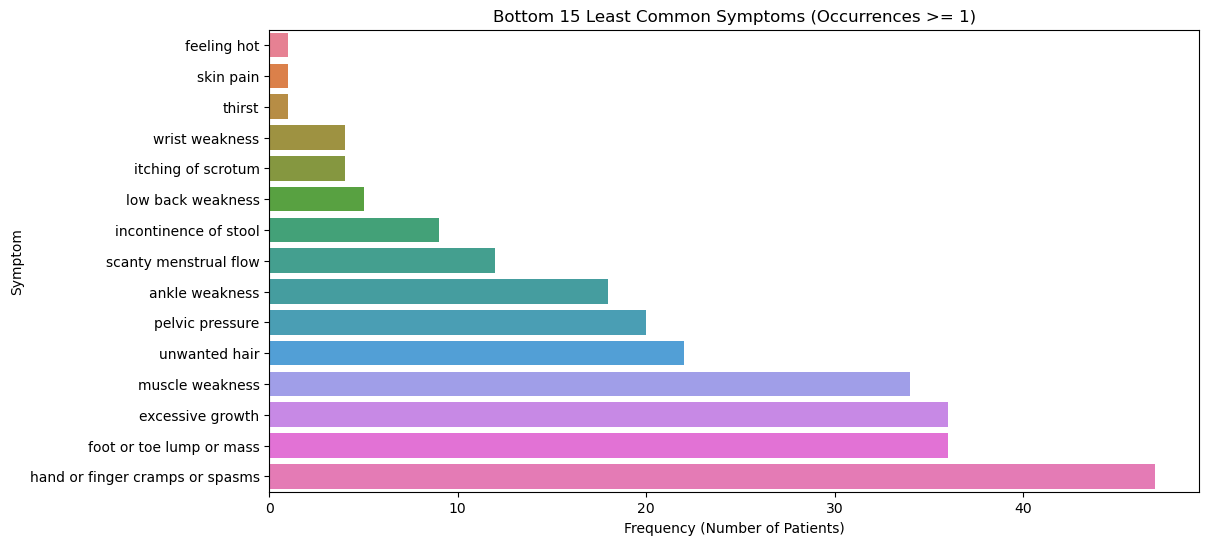

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolate the symptoms
symptoms_only = df.drop(columns=['diseases', 'Disease_Encoded'], errors='ignore')

# 2. Calculate the total frequency of each symptom
symptom_frequencies = symptoms_only.sum()

# 3. Identify symptoms with exactly 0 occurrences
zero_symptoms = symptom_frequencies[symptom_frequencies == 0]

print(f"Total symptoms with 0 occurrences: {len(zero_symptoms)}")
if len(zero_symptoms) > 0:
    print("Symptoms with 0 occurrences:\n", zero_symptoms.index.tolist())
else:
    print("There are no symptoms with 0 occurrences in this dataset.")

# 4. Filter for symptoms with 1 or more occurrences, sort them, and get the lowest 15
non_zero_symptoms = symptom_frequencies[symptom_frequencies >= 1].sort_values(ascending=True)
lowest_15_symptoms = non_zero_symptoms.head(15)

print("\nLowest 15 Symptoms (Occurrences >= 1):")
print(lowest_15_symptoms)

# 5. Visualize the lowest 15 non-zero symptoms
plt.figure(figsize=(12, 6))
sns.barplot(
    x=lowest_15_symptoms.values, 
    y=lowest_15_symptoms.index, 
    hue=lowest_15_symptoms.index, 
    legend=False
)
plt.title('Bottom 15 Least Common Symptoms (Occurrences >= 1)')
plt.xlabel('Frequency (Number of Patients)')
plt.ylabel('Symptom')
plt.show()